**PES1PG25CS071 TRIVENI R MAGADUM**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

In [ ]:
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

train_images = train_images[:1000] / 255.0
train_labels = train_labels[:1000]

test_images = test_images[:200] / 255.0
test_labels = test_labels[:200]

print(train_images.shape)
print(train_labels.shape)
print(test_images.shape)
print(test_labels.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(1000, 28, 28)
(1000,)
(200, 28, 28)
(200,)


In [ ]:
class Conv2D:
    def __init__(self, num_filters, filter_size):
        self.num_filters = num_filters
        self.filter_size = filter_size
        self.filters = np.random.randn(num_filters, filter_size, filter_size) / 9

    def iterate_regions(self, image):
        h, w = image.shape
        for i in range(h - self.filter_size + 1):
            for j in range(w - self.filter_size + 1):
                region = image[i:i+self.filter_size, j:j+self.filter_size]
                yield region, i, j

    def forward(self, input):
        self.last_input = input
        h, w = input.shape
        output = np.zeros((h - self.filter_size + 1, w - self.filter_size + 1, self.num_filters))

        for region, i, j in self.iterate_regions(input):
            output[i, j] = np.sum(region * self.filters, axis=(1, 2))

        return output

    def backward(self, d_L_d_out, learning_rate):
        d_L_d_filters = np.zeros(self.filters.shape)

        for region, i, j in self.iterate_regions(self.last_input):
            for f in range(self.num_filters):
                d_L_d_filters[f] += d_L_d_out[i, j, f] * region

        self.filters -= learning_rate * d_L_d_filters
        return None


class MaxPool2:
    def iterate_regions(self, image):
        h, w, num_filters = image.shape
        new_h = h // 2
        new_w = w // 2

        for i in range(new_h):
            for j in range(new_w):
                region = image[(i*2):(i*2+2), (j*2):(j*2+2)]
                yield region, i, j

    def forward(self, input):
        self.last_input = input
        h, w, num_filters = input.shape
        output = np.zeros((h // 2, w // 2, num_filters))

        for region, i, j in self.iterate_regions(input):
            output[i, j] = np.amax(region, axis=(0, 1))

        return output

    def backward(self, d_L_d_out):
        d_L_d_input = np.zeros(self.last_input.shape)

        for region, i, j in self.iterate_regions(self.last_input):
            h, w, f = region.shape
            max_vals = np.amax(region, axis=(0, 1))

            for i2 in range(h):
                for j2 in range(w):
                    for f2 in range(f):
                        if region[i2, j2, f2] == max_vals[f2]:
                            d_L_d_input[i*2+i2, j*2+j2, f2] = d_L_d_out[i, j, f2]

        return d_L_d_input


class Softmax:
    def __init__(self, input_len, nodes):
        self.weights = np.random.randn(input_len, nodes) / input_len
        self.biases = np.zeros(nodes)

    def forward(self, input):
        self.last_input_shape = input.shape
        input = input.flatten()
        self.last_input = input

        totals = np.dot(input, self.weights) + self.biases
        self.last_totals = totals

        exp = np.exp(totals - np.max(totals))
        return exp / np.sum(exp)

    def backward(self, d_L_d_out, learning_rate):
        for i, gradient in enumerate(d_L_d_out):
            if gradient == 0:
                continue

            t_exp = np.exp(self.last_totals - np.max(self.last_totals))
            S = np.sum(t_exp)

            d_out_d_t = -t_exp[i] * t_exp / (S ** 2)
            d_out_d_t[i] = t_exp[i] * (S - t_exp[i]) / (S ** 2)

            d_t_d_w = self.last_input
            d_t_d_b = 1
            d_t_d_inputs = self.weights

            d_L_d_t = gradient * d_out_d_t

            d_L_d_w = d_t_d_w[np.newaxis].T @ d_L_d_t[np.newaxis]
            d_L_d_b = d_L_d_t
            d_L_d_inputs = d_t_d_inputs @ d_L_d_t

            self.weights -= learning_rate * d_L_d_w
            self.biases -= learning_rate * d_L_d_b

            return d_L_d_inputs.reshape(self.last_input_shape)

In [ ]:
conv = Conv2D(8, 3)
pool = MaxPool2()
softmax = Softmax(13 * 13 * 8, 10)

In [ ]:
def forward(image, label):
    out = conv.forward(image)
    out = pool.forward(out)
    out = softmax.forward(out)

    loss = -np.log(out[label])
    accuracy = 1 if np.argmax(out) == label else 0

    return out, loss, accuracy


def train(image, label, learning_rate=0.005):
    out, loss, accuracy = forward(image, label)

    gradient = np.zeros(10)
    gradient[label] = -1 / out[label]

    gradient = softmax.backward(gradient, learning_rate)
    gradient = pool.backward(gradient)
    conv.backward(gradient, learning_rate)

    return loss, accuracy

In [ ]:
for epoch in range(5):
    print("Epoch", epoch + 1)

    loss = 0
    num_correct = 0

    for i, (image, label) in enumerate(zip(train_images, train_labels)):
        l, acc = train(image, label)
        loss += l
        num_correct += acc

        if (i + 1) % 100 == 0:
            print(
                "Step:", i + 1,
                "Loss:", round(loss / 100, 4),
                "Accuracy:", num_correct, "%"
            )
            loss = 0
            num_correct = 0

Epoch 1
Step: 100 Loss: 2.2146 Accuracy: 22 %
Step: 200 Loss: 1.9229 Accuracy: 36 %
Step: 300 Loss: 1.6776 Accuracy: 42 %
Step: 400 Loss: 1.4151 Accuracy: 53 %
Step: 500 Loss: 1.0223 Accuracy: 71 %
Step: 600 Loss: 1.216 Accuracy: 56 %
Step: 700 Loss: 0.9264 Accuracy: 72 %
Step: 800 Loss: 0.9309 Accuracy: 64 %
Step: 900 Loss: 0.9499 Accuracy: 68 %
Step: 1000 Loss: 1.0456 Accuracy: 67 %
Epoch 2
Step: 100 Loss: 0.7421 Accuracy: 78 %
Step: 200 Loss: 0.7482 Accuracy: 75 %
Step: 300 Loss: 1.0443 Accuracy: 66 %
Step: 400 Loss: 0.8932 Accuracy: 76 %
Step: 500 Loss: 0.6205 Accuracy: 81 %
Step: 600 Loss: 0.895 Accuracy: 70 %
Step: 700 Loss: 0.673 Accuracy: 79 %
Step: 800 Loss: 0.6741 Accuracy: 75 %
Step: 900 Loss: 0.7069 Accuracy: 75 %
Step: 1000 Loss: 0.7989 Accuracy: 77 %
Epoch 3
Step: 100 Loss: 0.5434 Accuracy: 83 %
Step: 200 Loss: 0.5873 Accuracy: 82 %
Step: 300 Loss: 0.8915 Accuracy: 76 %
Step: 400 Loss: 0.732 Accuracy: 79 %
Step: 500 Loss: 0.5326 Accuracy: 83 %
Step: 600 Loss: 0.7347 Accur

In [ ]:
loss = 0
num_correct = 0

for image, label in zip(test_images, test_labels):
    _, l, acc = forward(image, label)
    loss += l
    num_correct += acc

print("Test Loss:", loss / len(test_images))
print("Test Accuracy:", num_correct / len(test_images))

Test Loss: 0.5905459868232472
Test Accuracy: 0.775


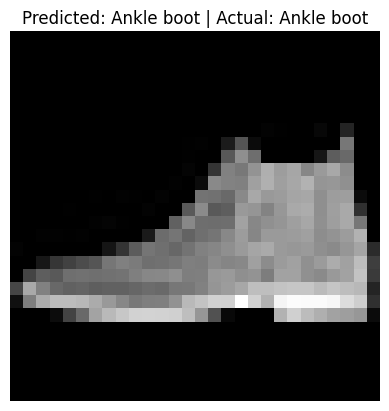

In [ ]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

index = 0
image = test_images[index]
label = test_labels[index]

prediction, _, _ = forward(image, label)

plt.imshow(image, cmap="gray")
plt.title("Predicted: " + class_names[np.argmax(prediction)] +
          " | Actual: " + class_names[label])
plt.axis("off")
plt.show()